# Stock Price Prediction Using Apache Spark and LSTM Neural Networks

#### Importing essential libraries:

- pyspark.sql.SparkSession: Important component for Spark operations
- pandas, numpy: Data manipulation libraries
- sklearn.preprocessing.MinMaxScaler: Feature scaling for neural network input
- torch, torch.nn: PyTorch framework for neural network
- sklearn.metrics: Evaluation metrics
- matplotlib: Visualization

In [1]:
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
from pyspark.sql.functions import col, max, min, avg
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ModuleNotFoundError: No module named 'pyspark'

#### Creates a Spark session. This session enables distributed computing capabilities for data processing.

In [2]:
spark = SparkSession.builder.appName("MSFT_Stock_Prediction").getOrCreate()

25/10/16 19:59:54 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


#### Importing the data

In [3]:
data_spark = spark.read.csv("file:///home/hduser/Desktop/msc-da-ca1-sem-2-VSKTC123/msft_historical.csv",header=True,inferSchema=True)

In [4]:
data_spark.show(5)

+----------+------------------+------------------+------------------+------------------+--------+
|      Date|             Close|              High|               Low|              Open|  Volume|
+----------+------------------+------------------+------------------+------------------+--------+
|      NULL|              MSFT|              MSFT|              MSFT|              MSFT|    MSFT|
|2015-01-02|39.933040618896484| 40.49668051755397|39.745162824511745|39.847641917608115|27913900|
|2015-01-05|39.565834045410156|   39.907432198522| 39.49751246013629|  39.5999915802946|39673900|
|2015-01-06|38.985111236572266|  39.9245101728321| 38.89117069139582| 39.60853100449049|36447900|
|2015-01-07| 39.48043441772461|39.676854100469185|38.848476005025134|  39.2669343376432|29114100|
+----------+------------------+------------------+------------------+------------------+--------+
only showing top 5 rows



### Summarizing statistics max, min, avg for numeric columns

In [7]:
numeric_cols = ['Close', 'High', 'Low', 'Open', 'Volume']
for c in numeric_cols:
    data_spark = data_spark.withColumn(c, col(c).cast('double'))
agg_functions = [max, min, avg]
agg_exprs = []
for c in numeric_cols:
    for f in agg_functions:
        agg_exprs.append(f(col(c)).alias(f"{f.__name__}_{c}"))
summary_df = data_spark.select(*agg_exprs)
summary = summary_df.collect()[0]
print("Summary Statistics for MSFT Historical Data:")
for c in numeric_cols:
    print(f"{c}:")
    print(f"  Max: {summary[f'max_{c}']:.2f}")
    print(f"  Min: {summary[f'min_{c}']:.2f}")
    print(f"  Mean: {summary[f'avg_{c}']:.2f}")

Summary Statistics for MSFT Historical Data:
Close:
  Max: 534.76
  Min: 34.50
  Mean: 199.81
High:
  Max: 554.54
  Min: 35.04
  Mean: 201.63
Low:
  Max: 531.03
  Min: 34.36
  Mean: 197.80
Open:
  Max: 554.32
  Min: 34.66
  Mean: 199.76
Volume:
  Max: 169164000.00
  Min: 7164500.00
  Mean: 28405411.58


### Data Cleaning and Feature Selection
- Selects columns (Date and Close price)
- 'Close' to double data type, ensuring numerical consistency for downstream processing

This step focuses on the target variable for univariate time series prediction.

In [8]:
data_spark = data_spark.select('Date', data_spark['Close'].cast('double'))

In [9]:
data_spark.show(5)

+----------+------------------+
|      Date|             Close|
+----------+------------------+
|      NULL|              NULL|
|2015-01-02|39.933040618896484|
|2015-01-05|39.565834045410156|
|2015-01-06|38.985111236572266|
|2015-01-07| 39.48043441772461|
+----------+------------------+
only showing top 5 rows



- Conversion to Pandas and clean
- Removes rows with missing values

In [10]:
prices_pd = data_spark.select('Close').toPandas()
prices_pd['Close'] = pd.to_numeric(prices_pd['Close'], errors='coerce')
prices_pd = prices_pd.dropna(subset=['Close'])

### Feature Engineering and Normalization
- Converts 1D array to 2D array by MinMaxScaler
- Min-Max scaling transforms prices to the [0, 1]
- This normalization is important for LSTM because it prevents the vanishing gradient problem.

In [11]:
prices = prices_pd['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

#### Sequence Creation for Time Series
 - Input (X): 60 consecutive days of closing prices
 - Output (y): Next day's closing price (day 61)
####  Example:
- Sequence 1: Days 1-60 = Predict Day 61
- Sequence 2: Days 2-61 = Predict Day 62
- Sequence n: Days n-(n+59) = Predict Day n+60 

In [12]:
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)
seq_len = 60
X, y = create_sequences(scaled_prices, seq_len)

#### Data Augmentation
- Splitting data into train and test (80-20)
- Adding Gaussian noise (Mue = 0, Sigma = 0.01) to training sequences
- Doubling training data by adding both original and noisy values
#### Usecases
- Improves model performance to minor fluctuations
- Reduces overfitting by introducing controlled variables

In [13]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

noise_level = 0.01
X_train_aug = X_train + np.random.normal(0, noise_level, X_train.shape)
X_train = np.vstack((X_train, X_train_aug))
y_train = np.vstack((y_train, y_train))

- Convert to PyTorch tensors
- Creates a DataLoader for efficient batch processing

In [14]:
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

### NEURAL NETWORK ARCHITECTURE
- Input Layer (input_size=1):
Contains one feature: normalized closing price
Sequence length- 60 timesteps.
- LSTM Layer (hidden_layer_size=100):Contains 100 memory cells
(Each cell maintains:
Cell state: Long-term memory,
Hidden state: Short-term memory)
- Gates mechanism: 1.Forget gate: Decides what information to delete,
2.Input gate: Controls new information addition,
3.Output gate: Determines hidden state output
- Fully Connected Layer (output_size=1):single predicted price, 
Uses only the last timestep's hidden state.
- Mean Squared Error, loss function and Adam Optimizer added
- Adam Optimizer: Adaptive learning rate optimization acts as optimizer
- Learning rate: Controls step size during gradient descent.

In [15]:
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=100, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        lstm_out, _ = self.lstm(input_seq)
        predictions = self.linear(lstm_out[:, -1, :])
        return predictions

model = LSTM()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

#### Training the Model
- Epoch Loop (50 iterations):Each epoch processes entire training dataset once
- model train: Activates training mode (enables dropout, batch normalization updates)
- Batch Processing: Iterates through batches from DataLoader. Each batch contains 32 sequences
- Loss calculation: Compares predictions with actual values, gives prediction error

In [16]:
epochs = 50  
for i in range(epochs):
    model.train()
    for seq, labels in train_loader:
        optimizer.zero_grad()
        y_pred = model(seq)
        loss = loss_function(y_pred, labels)
        loss.backward()
        optimizer.step()
    if (i + 1) % 1 == 0:
        print(f'Epoch {i + 1}/{epochs}, Loss: {loss.item():.6f}')

Epoch 1/50, Loss: 0.000102
Epoch 2/50, Loss: 0.000164
Epoch 3/50, Loss: 0.000022
Epoch 4/50, Loss: 0.000089
Epoch 5/50, Loss: 0.000390
Epoch 6/50, Loss: 0.000012
Epoch 7/50, Loss: 0.000316
Epoch 8/50, Loss: 0.000031
Epoch 9/50, Loss: 0.000117
Epoch 10/50, Loss: 0.000116
Epoch 11/50, Loss: 0.000004
Epoch 12/50, Loss: 0.000193
Epoch 13/50, Loss: 0.000007
Epoch 14/50, Loss: 0.000098
Epoch 15/50, Loss: 0.000218
Epoch 16/50, Loss: 0.000223
Epoch 17/50, Loss: 0.000024
Epoch 18/50, Loss: 0.000090
Epoch 19/50, Loss: 0.000186
Epoch 20/50, Loss: 0.000229
Epoch 21/50, Loss: 0.000009
Epoch 22/50, Loss: 0.000062
Epoch 23/50, Loss: 0.000062
Epoch 24/50, Loss: 0.000125
Epoch 25/50, Loss: 0.000016
Epoch 26/50, Loss: 0.000024
Epoch 27/50, Loss: 0.000091
Epoch 28/50, Loss: 0.000182
Epoch 29/50, Loss: 0.000115
Epoch 30/50, Loss: 0.000061
Epoch 31/50, Loss: 0.000289
Epoch 32/50, Loss: 0.000294
Epoch 33/50, Loss: 0.000093
Epoch 34/50, Loss: 0.000055
Epoch 35/50, Loss: 0.000084
Epoch 36/50, Loss: 0.000018
E

#### MODEL EVALUATION
- Disables gradient computation (reduces memory, speeds up)
- Removes tensor from computation graph, Moves tensor to CPU memory and Converts PyTorch tensor to NumPy array
#### Inverse scaling
- Reverses Min-Max scaling to obtain actual values

In [17]:
model.eval()
with torch.no_grad():
    test_preds = model(X_test).detach().cpu().numpy()

actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))
predicted_prices = scaler.inverse_transform(test_preds.reshape(-1, 1))

#### Evaluate Metrics
- Root Mean Squared Error
- Mean Absolute Error 
- Mean Absolute Percentage Error
- R² Score
- Directional accuracy

In [18]:
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae = mean_absolute_error(actual_prices, predicted_prices)
mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
r2 = r2_score(actual_prices, predicted_prices)

actual_diff = np.diff(actual_prices.ravel())
pred_diff = np.diff(predicted_prices.ravel())
Difference_acc = actual_diff-pred_diff
direction_acc = np.mean((actual_diff * pred_diff) > 0) * 100

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R² Score: {r2:.4f}")
print(f"Directional Accuracy: {direction_acc:.2f}%")

Root Mean Squared Error (RMSE): 8.42
Mean Absolute Error (MAE): 6.61
Mean Absolute Percentage Error (MAPE): 1.55%
R² Score: 0.9725
Directional Accuracy: 51.70%


##### Visualization


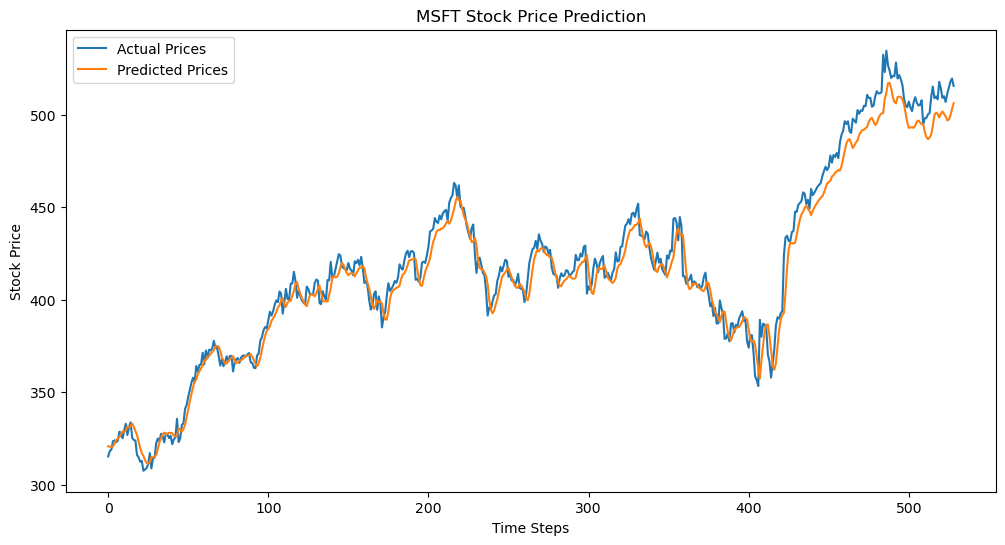

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual Prices')
plt.plot(predicted_prices, label='Predicted Prices')
plt.title('MSFT Stock Price Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

#### NEXT DAY PREDICTION

1. Create sequences – Use past seq_length days to predict the next day.
2. Prepare input – Take the last sequence of prices and convert to a tensor.
3. Predict – Feed the sequence into the trained model to get the next day’s scaled price.
4. Inverse transform – Convert the scaled prediction back to the actual price.
5. And predicted closing price for the next day.


In [21]:
seq_length = 60
last_sequence = scaled_prices[-seq_length:]
last_sequence = last_sequence.reshape(1, seq_length, 1)

last_sequence_tensor = torch.from_numpy(last_sequence).float()
next_pred_scaled = model(last_sequence_tensor).detach().cpu().numpy()
next_price = scaler.nverse_transform(next_pred_scaled)[0][0]

print(f"Predicted closing price for the next day: ${next_price:.2f}")

Predicted closing price for the next day: $506.37


In [ ]:
def create_seq(data,n=60):
    X,y=[],[]
    for i in range(len(data)-n):
        X.append(data[i:i+n])
        y.append(data[i+n])#
    return np.array(X),np.array(y)
X,y=create_seq(scaled)
split=int(0.8*len(X))
X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

In [ ]:
noise=np.random.normal(0,0.01.X_train.shape)
X_train,X_test=np.vstack(X_train,X_train+noise)
y_train,y_test=np.vstack(y_train,y_train)

In [ ]:
X_train=torch.tensor(X_train,dtype=torch.float32)
X_test=torch.tensor(X_test,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.float32)
y_test=torch.tensor(y_train,dtype=torch.float32)

In [ ]:
train_loader=DataLoader(TensorDataset(X_train,y_train),batch_size=32,shuffle=True)

In [ ]:
class LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm=nn.LSTM(1,100,batch_first=True)
        self.fc=nn.Linear(100,1)
    def forward(self,x):
        out,_=self.lstm(x)
        return self.fc(out[:,-1,:])

In [ ]:
model=LSTM()
loss_fn=nn.Module()
optimizer=torch.optim.Adam(model.parameters(),lr=0.0005)


In [ ]:
for epoch in range(50):
    model.train()#
    for xb,yb in train_loader:
        optimizer.zero_grid()
        loss=loss_fn(model(xb),yb)
        loss.backward()
        optimizer.step()
    print(f'Epoch{epoch+1}/50|Loss{loss.item():.6f}')

In [ ]:
model.eval()
with torch.no_grid():
    preds=model(X_test).numpy()
actual=scaler.inverse_tranform(y_test.numpy())
preducted=scaler.inverse_tranform(preds)

In [ ]:
last_seq=torch.tensor(sclaed_prices[-60:].reshape(1,60,1),
                      dtype=torch.float32)
next_price=model(last_seq).item()
next_price=scaler.inverse_transform([[next_price]])[0][0]
print(f'Next day predicted price:${next_price.2f}')

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("msft_historical.csv")
df = df[['Close']]
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df.dropna(inplace=True)

In [4]:
prices = df.values
scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(prices)

In [7]:
def create_sequence(data,seq_len=60):
    X,y=[],[]
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)
X,y = create_sequence(scaled_prices)

In [16]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [20]:
noise = np.random.normal(0, 0.01, X_train.shape)
X_train = np.vstack((X_train, X_train + noise))
y_train = np.vstack((y_train, y_train))

In [21]:
X_train=torch.tensor(X_train,dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.float32)

In [26]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

In [24]:
class LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm=nn.LSTM(1,100,batch_first=True)
        self.fc=nn.Linear(100,1)
    def forward(self,x):
        out,_=self.lstm(x)
        return self.fc(out[:,-1])
model=LSTM()      
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [27]:
for epoch in range(50):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/50 | Loss: {loss.item():.6f}")

Epoch 1/50 | Loss: 0.002161
Epoch 2/50 | Loss: 0.000352
Epoch 3/50 | Loss: 0.000223
Epoch 4/50 | Loss: 0.000224
Epoch 5/50 | Loss: 0.000297
Epoch 6/50 | Loss: 0.000206
Epoch 7/50 | Loss: 0.000224
Epoch 8/50 | Loss: 0.000099
Epoch 9/50 | Loss: 0.000152
Epoch 10/50 | Loss: 0.000198
Epoch 11/50 | Loss: 0.000179
Epoch 12/50 | Loss: 0.000192
Epoch 13/50 | Loss: 0.000065
Epoch 14/50 | Loss: 0.000253
Epoch 15/50 | Loss: 0.000189
Epoch 16/50 | Loss: 0.000095
Epoch 17/50 | Loss: 0.000105
Epoch 18/50 | Loss: 0.000156
Epoch 19/50 | Loss: 0.000134
Epoch 20/50 | Loss: 0.000158
Epoch 21/50 | Loss: 0.000122
Epoch 22/50 | Loss: 0.000087
Epoch 23/50 | Loss: 0.000116
Epoch 24/50 | Loss: 0.000078
Epoch 25/50 | Loss: 0.000087
Epoch 26/50 | Loss: 0.000111
Epoch 27/50 | Loss: 0.000172
Epoch 28/50 | Loss: 0.000114
Epoch 29/50 | Loss: 0.000161
Epoch 30/50 | Loss: 0.000139
Epoch 31/50 | Loss: 0.000052
Epoch 32/50 | Loss: 0.000209
Epoch 33/50 | Loss: 0.000173
Epoch 34/50 | Loss: 0.000092
Epoch 35/50 | Loss: 0.0

In [30]:
model.eval()
with torch.no_grad():
    preds = model(X_test).numpy()
actual = scaler.inverse_transform(y_test.numpy())
predicted = scaler.inverse_transform(preds)

In [32]:
rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
r2 = r2_score(actual, predicted)
direction_acc = np.mean(
    np.sign(np.diff(actual.ravel())) ==
    np.sign(np.diff(predicted.ravel()))
) * 100
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.4f}")
print(f"Directional Accuracy: {direction_acc:.2f}%")

RMSE: 10.08
MAE: 8.44
MAPE: 1.94%
R²: 0.9490
Directional Accuracy: 52.45%


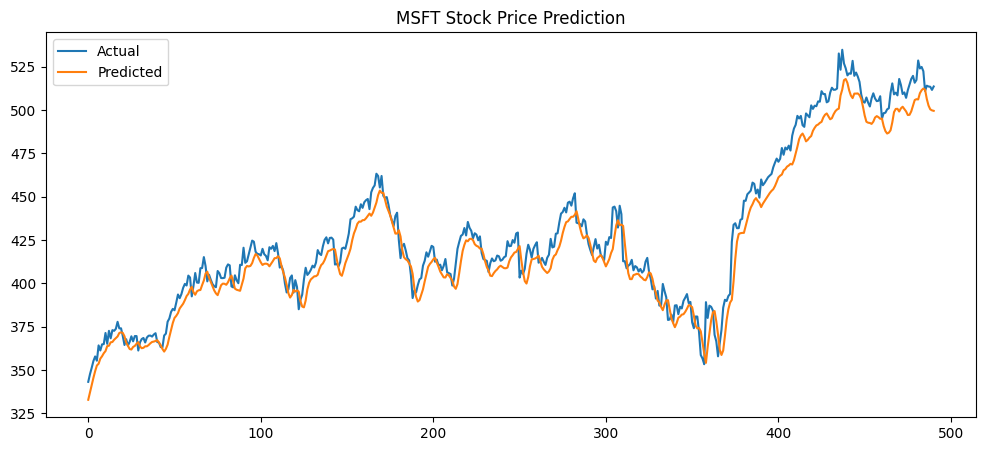

In [33]:
plt.figure(figsize=(12,5))
plt.plot(actual, label="Actual")
plt.plot(predicted, label="Predicted")
plt.legend()
plt.title("MSFT Stock Price Prediction")
plt.show()

In [34]:
last_seq = torch.tensor(
    scaled_prices[-60:].reshape(1, 60, 1),
    dtype=torch.float32
)

next_price = model(last_seq).item()
next_price = scaler.inverse_transform([[next_price]])[0][0]

print(f"Next day predicted price: ${next_price:.2f}")

Next day predicted price: $500.35
